# World Bank Global Economic Prospects — GDP Growth Forecasts

The `macro_data` package's pipeline (`catalog.yaml` → `pipeline.py` →
`store.py`) assumes every series is a growing history of actuals, fetched
incrementally from `store.last_date() + 1 day` onward. World Bank's
**Global Economic Prospects (GEP)** data is the opposite: a small, fully
revised forecast vintage published a couple of times a year, where old
"forecast" years get overwritten by the next vintage rather than extended.
Forcing it through `normalize()`/`append()` would misrepresent revisions as
new history — so, like `fx_ohlcv_query.ipynb` does for OHLCV bars, this
notebook queries the API directly and stays outside the canonical store.

GEP data lives in World Bank DataBank **source 27**, reachable through the
same `api.worldbank.org/v2` endpoint the project's `worldbank` source
already calls — just with `source=27` instead of the default WDI source
(`2`). It has exactly one indicator, `NYGDPMKTPKDZ` ("GDP growth, constant
2010-19 prices"), covering 2023–2028 with every row flagged as a forecast
(`obs_status == "F"`).

Sections:
1. Fetching GEP forecasts
2. Confirming these are forecast values
3. Comparing GDP growth trajectories
4. Saving the snapshot to CSV

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_rows", 20)
%matplotlib inline

GEP_URL = "https://api.worldbank.org/v2/country/{codes}/indicator/NYGDPMKTPKDZ"


def fetch_gep_forecast(country_codes: list[str]) -> pd.DataFrame:
    """Query World Bank Global Economic Prospects (source=27) GDP growth forecasts."""
    resp = requests.get(
        GEP_URL.format(codes=";".join(country_codes)),
        params={"source": 27, "format": "json", "per_page": 200},
        timeout=30,
    )
    resp.raise_for_status()
    payload = resp.json()
    rows = payload[1] if len(payload) > 1 and payload[1] else []
    df = pd.DataFrame(
        {
            "country": r["country"]["value"],
            "year": int(r["date"]),
            "value": r["value"],
            "obs_status": r["obs_status"],
        }
        for r in rows
    )
    return df.sort_values(["country", "year"]).reset_index(drop=True)

## 1. Fetching GEP forecasts

Thailand (`THA`), the United States (`USA`), and the World aggregate
(`1T` — World Bank's own code for "World (WBG members)"; the ISO3 code
`WLD` used elsewhere in this project returns nothing under source 27).

In [2]:
forecast = fetch_gep_forecast(["THA", "USA", "1T"])
forecast

,country,year,value,obs_status
0,Thailand,2023,2.2,F
1,Thailand,2024,2.9,F
2,Thailand,2025,2.4,F
3,Thailand,2026,1.7,F
4,Thailand,2027,2.1,F
5,Thailand,2028,2.4,F
6,United States,2023,2.9,F
7,United States,2024,2.8,F
8,United States,2025,2.1,F
9,United States,2026,2.2,F


## 2. Confirming these are forecast values

Every row in this dataset — including years that have already
passed — carries `obs_status == "F"`, because GEP publishes a fully
model-based vintage rather than mixing in reported actuals.

In [3]:
forecast["obs_status"].unique()

<StringArray>
['F']
Length: 1, dtype: str

## 3. Comparing GDP growth trajectories

Thailand, the US, and the World aggregate, 2023–2028.

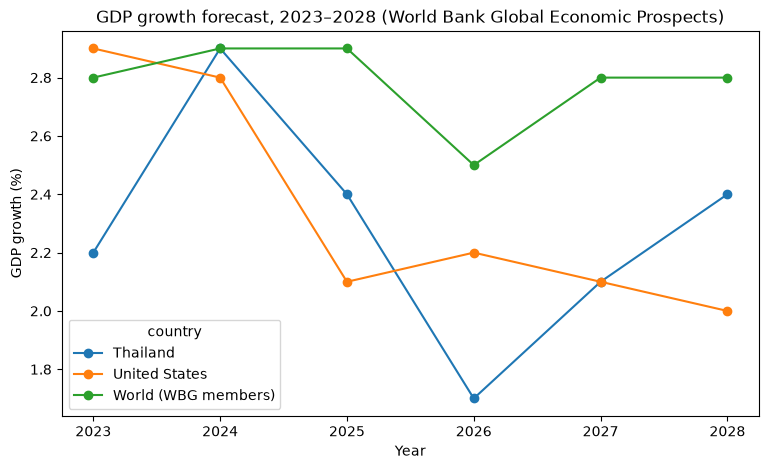

In [4]:
pivot = forecast.pivot(index="year", columns="country", values="value")

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(ax=ax, marker="o", title="GDP growth forecast, 2023–2028 (World Bank Global Economic Prospects)")
ax.set_ylabel("GDP growth (%)")
ax.set_xlabel("Year")
plt.show()

## 4. Saving the snapshot to CSV

This is a forecast vintage, not a growing history of actuals, so it's saved
to its own folder — `data/worldbank_gep/` — separate from `data/worldbank/`,
which holds the actuals fetched through the canonical `worldbank` source.

In [5]:
gep_dir = Path("..") / "data" / "worldbank_gep"
gep_dir.mkdir(parents=True, exist_ok=True)
forecast.to_csv(gep_dir / "gdp_growth_forecast.csv", index=False)

sorted(p.name for p in gep_dir.glob("*.csv"))

['gdp_growth_forecast.csv']